In [4]:
import numpy as np
import pandas as pd
import geopandas as gpd
# ga_results = pd.read_csv("/home/felipe/Desktop/Trabajo/Wind Farm Layout/results/ga_result_spacing_curve.csv")
ga_results = pd.read_csv("/home/felipe/Desktop/Trabajo/WFL_scripts/results/ga_result_1.csv")

gdf = gpd.read_file("/home/felipe/Desktop/Trabajo/Wind Farm Layout/data/eolico_10_m/Zona_F_Eolico_10m.shp")
gdf = gdf.to_crs(epsg=9377)
polygon_1 = gdf.geometry.iloc[33601] # e_10m_33602
polygon_2 = gdf.geometry.iloc[36598] # e_10m_36599
polygon_3  =gdf.geometry.iloc[34267] #e_10m_34268##BAD
polygon_4  =gdf.geometry.iloc[36661] #e_10m_36662##BUENO
polygon_5 = gdf.geometry.iloc[33929] # e_10m_33930
polygon_6 = gdf.geometry.iloc[36643] # e_10m_36644

geometries = {
    "sb": gdf.geometry.iloc[33601], # e_10m_33602,
    "sg": gdf.geometry.iloc[36598], # e_10m_36599,
    "mb": gdf.geometry.iloc[34267], #e_10m_34268##BAD,
    "mg": gdf.geometry.iloc[36661], #e_10m_36662##BUENO,
    "bb": gdf.geometry.iloc[33929], # e_10m_33930,
    "bg": gdf.geometry.iloc[36643], # e_10m_36644,
}



Text(0.5, 1.0, 'BG')

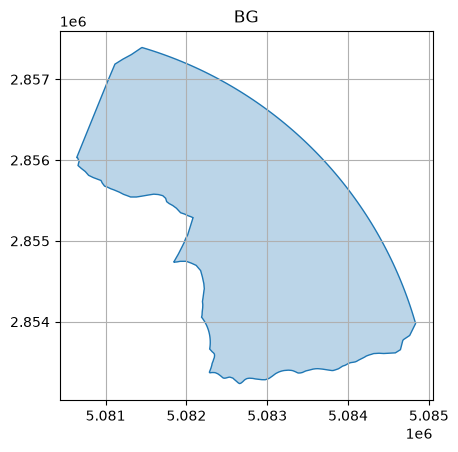

In [20]:
from shapely.plotting import plot_polygon
import matplotlib.pyplot as plt
plot_polygon(geometries["bg"], add_points=False)
plt.title("BG")

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_heatmap_ax(
    fig, ax, df, config_val, num_col, fmt=".2f", cmap="viridis"
):
    """Plots an annotated heatmap of 'fn' vs 'polygon' for a selected 'config' category

    onto a provided Matplotlib Figure and Axes object.

    Parameters:
    -----------
    fig : matplotlib.figure.Figure
        The parent figure object (needed for adding the colorbar).
    ax : matplotlib.axes.Axes
        The specific subplot axes where the heatmap will be drawn.
    df : pandas.DataFrame
        Input DataFrame.
    config_val : str or int
        The category value in the 'config' column to filter by.
    num_col : str
        The numerical column to plot ('fitness', 'aep_wake', 'park_cf',
        'park_loss').
    fmt : str, default '.2f'
        Format specifier for cell values (e.g., '.2f', '.1f', '.0f').
    cmap : str, default 'viridis'
        Matplotlib colormap scheme.
    """
    # 1. Filter DataFrame by the given config
    filtered_df = df[df["config"] == config_val]

    if filtered_df.empty:
        raise ValueError(f"No rows found for config = '{config_val}'")

    # 2. Pivot the data (Swapped index and columns)
    pivot_df = filtered_df.pivot(index="fn", columns="polygon", values=num_col)

    data_matrix = pivot_df.values
    row_labels = pivot_df.index.tolist()
    col_labels = pivot_df.columns.tolist()

    # 3. Draw heatmap on the passed `ax`
    im = ax.imshow(data_matrix, cmap=cmap, aspect="auto")

    # Add colorbar attached to the parent `fig`
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(num_col, rotation=-90, va="bottom", fontsize=10)

    # Set tick labels
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticklabels(row_labels, fontsize=10)

    # Axis labels and title (Swapped x and y labels)
    ax.set_xlabel("Polygon", fontsize=11)
    ax.set_ylabel("FN", fontsize=11)
    ax.set_title(f"{num_col}", fontsize=12, pad=10)

    # 4. Annotate cells with adaptive text color for readability
    norm = im.norm
    cmap_obj = plt.get_cmap(cmap)

    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            val = data_matrix[i, j]
            if not np.isnan(val):
                # Calculate relative luminance to decide white/black text
                rgba = cmap_obj(norm(val))
                luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                text_color = "white" if luminance < 0.5 else "black"

                ax.text(
                    j,
                    i,
                    f"{val:{fmt}}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontweight="bold",
                )

In [6]:
ga_results["polygon"].unique()

<StringArray>
['sb', 'sg', 'mb', 'mg', 'bb', 'bg']
Length: 6, dtype: str

In [5]:
ga_results.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       108 non-null    int64  
 1   polygon          108 non-null    str    
 2   fn               108 non-null    str    
 3   config           108 non-null    str    
 4   fitness          108 non-null    float64
 5   aep_wake         108 non-null    float64
 6   park_cf          108 non-null    float64
 7   park_loss        108 non-null    float64
 8   history          108 non-null    str    
 9   fitness_history  108 non-null    str    
 10  x_positions      108 non-null    str    
 11  y_positions      108 non-null    str    
 12  spacing          108 non-null    float64
 13  best_result_x    108 non-null    str    
 14  best_result_y    108 non-null    str    
 15  n_turbinas       108 non-null    int64  
 16  error            0 non-null      float64
dtypes: float64(6), int64(2), st

In [23]:
ga_results["config"].unique()

<StringArray>
['ga_config_2', 'ga_config_3']
Length: 2, dtype: str

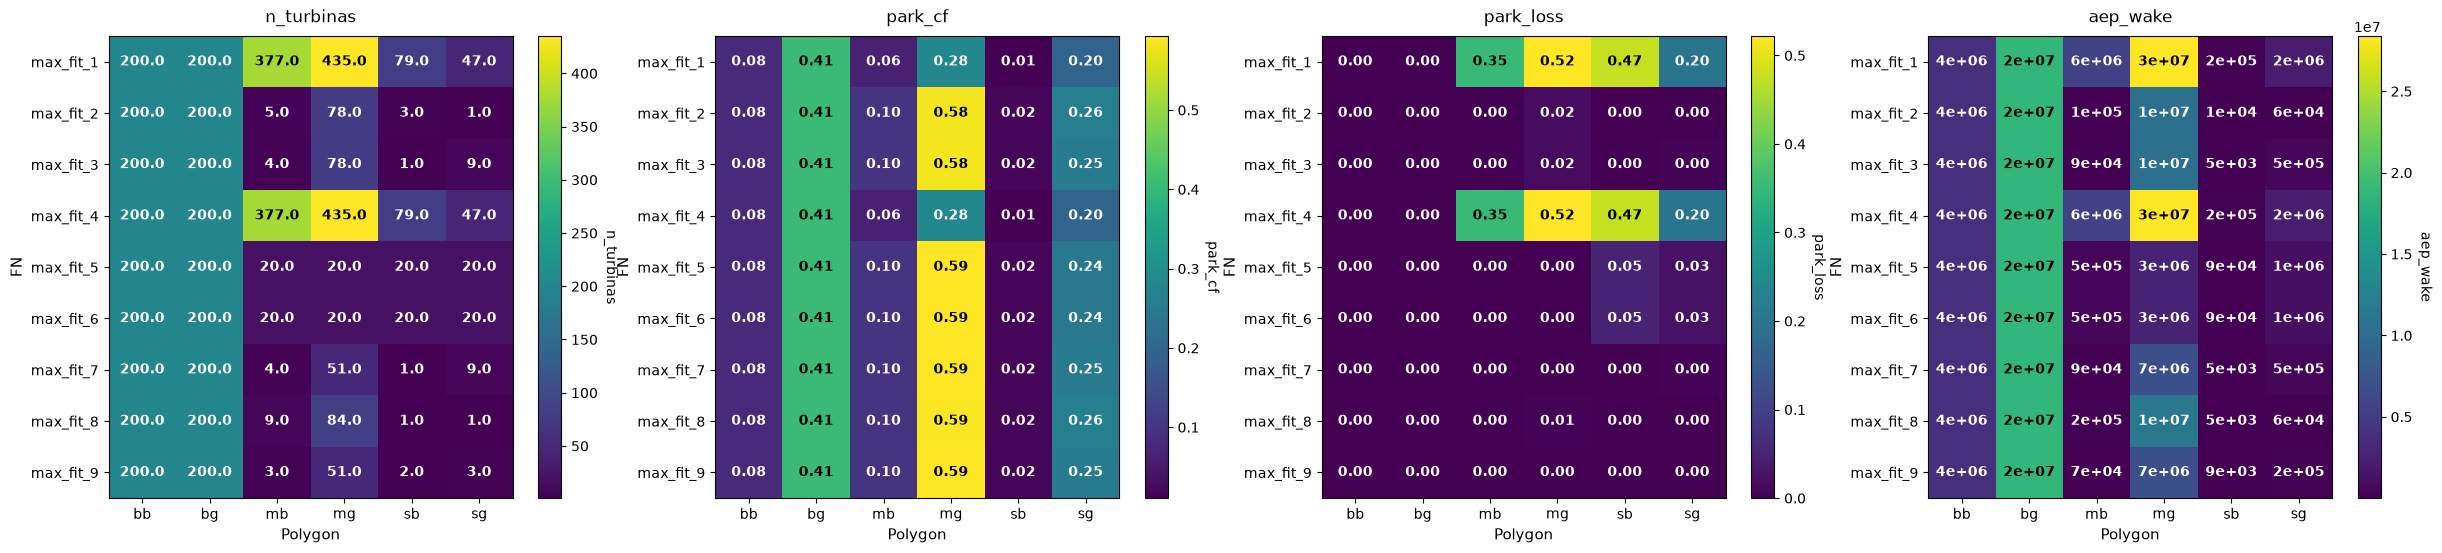

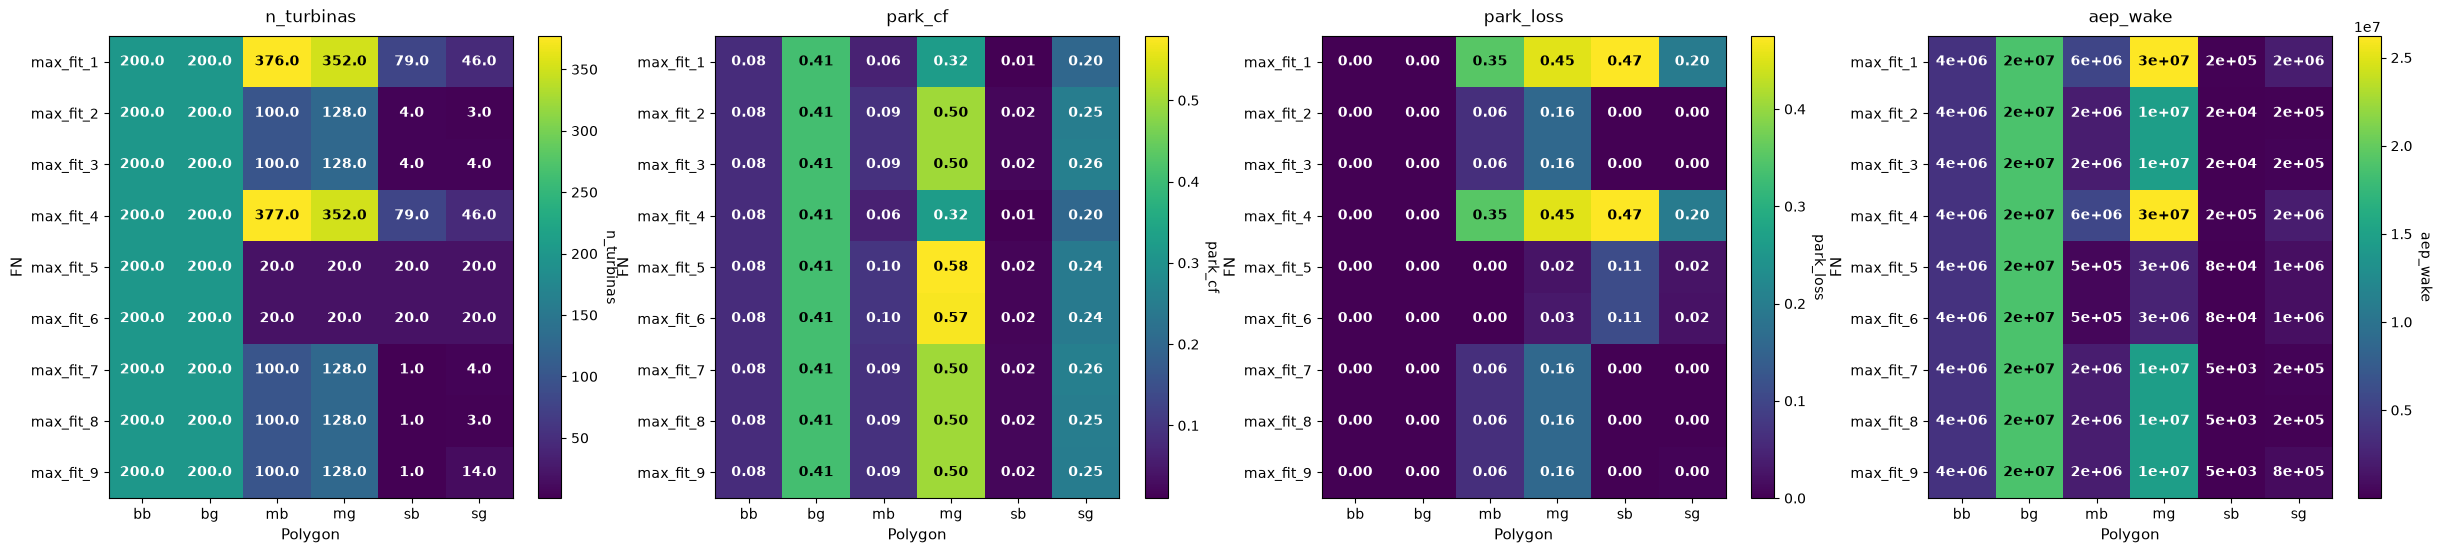

In [24]:
import math
def plot_all_results(df):
    configs = df["config"].unique()

    for idx, c in enumerate(configs):
        fig, axes = plt.subplots(1, 4, figsize=(30, 6))
        plot_heatmap_ax(fig, axes[0], df, c, "n_turbinas", fmt=".1f")
        plot_heatmap_ax(fig, axes[1], df, c, "park_cf")
        plot_heatmap_ax(fig, axes[2], df, c, "park_loss")
        plot_heatmap_ax(fig, axes[3], df, c, "aep_wake", fmt=".0e")

plot_all_results(ga_results)